In [1]:
!mkdir -p vision_cnn_project/src
!mkdir -p vision_cnn_project/data
%cd vision_cnn_project

/content/vision_cnn_project


In [2]:
!pip install torch torchvision matplotlib

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [1]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

NameError: name 'transforms' is not defined

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [7]:
!pip install torch torchvision matplotlib

In [8]:
!mkdir -p vision_cnn_project/src
!mkdir -p vision_cnn_project/data
%cd vision_cnn_project

/content/vision_cnn_project


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

100%|██████████| 170M/170M [00:02<00:00, 80.1MB/s]


Training examples: 50000
Test examples: 10000


In [11]:
classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

print(classes)

('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [12]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train loader batches:", len(train_loader))
print("Test loader batches:", len(test_loader))

Train loader batches: 782
Test loader batches: 157


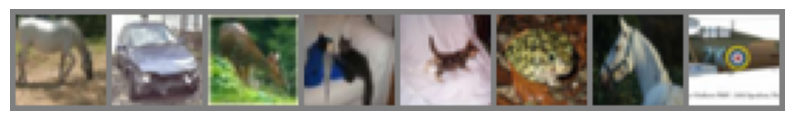

Labels: ['horse', 'automobile', 'deer', 'cat', 'cat', 'frog', 'horse', 'airplane']


In [13]:
def imshow(img):
    img = img / 2 + 0.5   # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [classes[labels[j]] for j in range(8)])

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # [batch, 32, 16, 16]
        x = self.pool(self.relu(self.conv2(x)))   # [batch, 64, 8, 8]
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [15]:
nn.Conv2d(3, 32, kernel_size=3, padding=1)

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [16]:
nn.Conv2d(32, 64, kernel_size=3, padding=1)

Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [17]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}")

print("Finished Training")

Epoch [1/5], Loss: 1.3364
Epoch [2/5], Loss: 0.9643
Epoch [3/5], Loss: 0.8084
Epoch [4/5], Loss: 0.6946
Epoch [5/5], Loss: 0.5941
Finished Training


In [20]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.43%


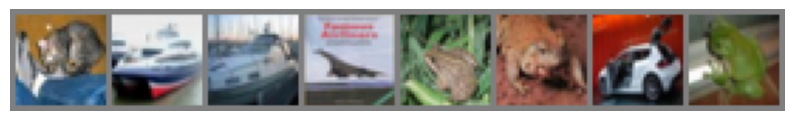

True labels:      ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']
Predicted labels: ['cat', 'ship', 'airplane', 'airplane', 'deer', 'frog', 'automobile', 'frog']


In [21]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

imshow(torchvision.utils.make_grid(images[:8]))
print("True labels:     ", [classes[labels[j]] for j in range(8)])
print("Predicted labels:", [classes[predicted[j]] for j in range(8)])

In [22]:
torch.save(model.state_dict(), "cnn_cifar10.pth")
print("Model saved!")

Model saved!


In [24]:
train_losses = []

num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0

    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("Finished Training")

Epoch [1/5], Loss: 0.5004
Epoch [2/5], Loss: 0.4119
Epoch [3/5], Loss: 0.3342
Epoch [4/5], Loss: 0.2651
Epoch [5/5], Loss: 0.2071
Finished Training


In [25]:
import json

with open("training_losses.json", "w") as f:
    json.dump(train_losses, f)

print("Training losses saved!")

Training losses saved!


In [26]:
!zip -r vision_cnn_project_checkpoint.zip .

  adding: training_losses.json (deflated 30%)
  adding: data/ (stored 0%)
  adding: data/cifar-10-python.tar.gz (deflated 0%)
  adding: data/cifar-10-batches-py/ (stored 0%)
  adding: data/cifar-10-batches-py/readme.html (stored 0%)
  adding: data/cifar-10-batches-py/data_batch_1 (deflated 9%)
  adding: data/cifar-10-batches-py/data_batch_3 (deflated 8%)
  adding: data/cifar-10-batches-py/test_batch (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_4 (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_2 (deflated 8%)
  adding: data/cifar-10-batches-py/batches.meta (deflated 12%)
  adding: data/cifar-10-batches-py/data_batch_5 (deflated 8%)
  adding: cnn_cifar10.pth (deflated 7%)
  adding: src/ (stored 0%)


In [27]:
from google.colab import files
files.download("vision_cnn_project_checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

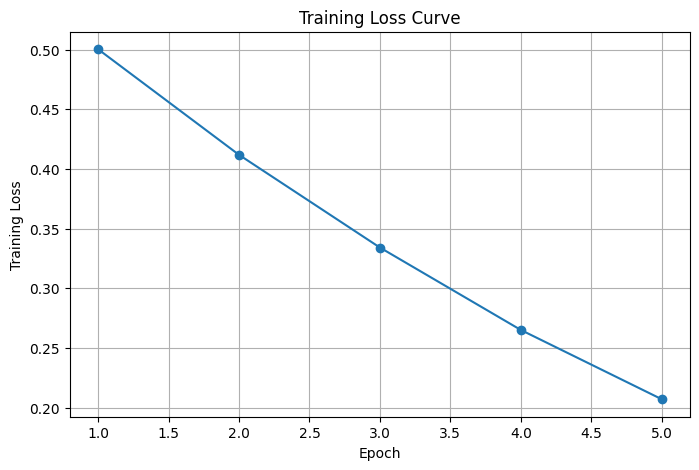

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [30]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [31]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[793  10  63  22  15  20   5  17  36  19]
 [ 43 743   9  11   5  12  12   8  24 133]
 [ 60   5 624  60  55  62  71  49   7   7]
 [ 19   4  90 534  45 215  52  25   5  11]
 [ 30   3  93  84 582  60  64  74   9   1]
 [ 18   4  54 142  21 693  20  42   2   4]
 [  4   3  42  77  23  28 813   4   6   0]
 [ 18   1  38  31  30  74   8 792   1   7]
 [ 96  33  25  15   8  17   8   7 764  27]
 [ 51  49  14  16   2  14   4  34  24 792]]


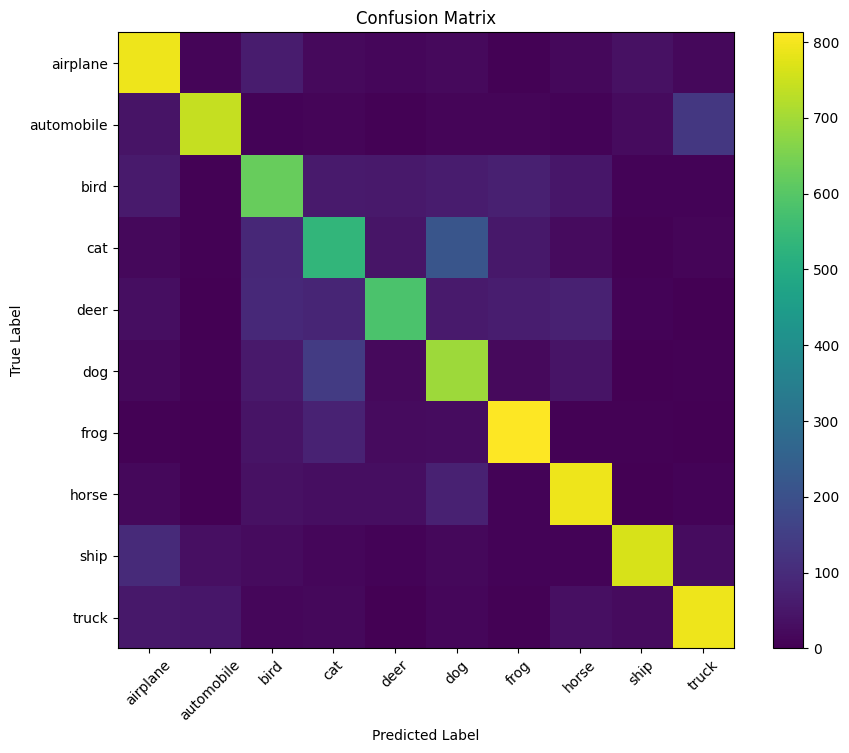

In [32]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

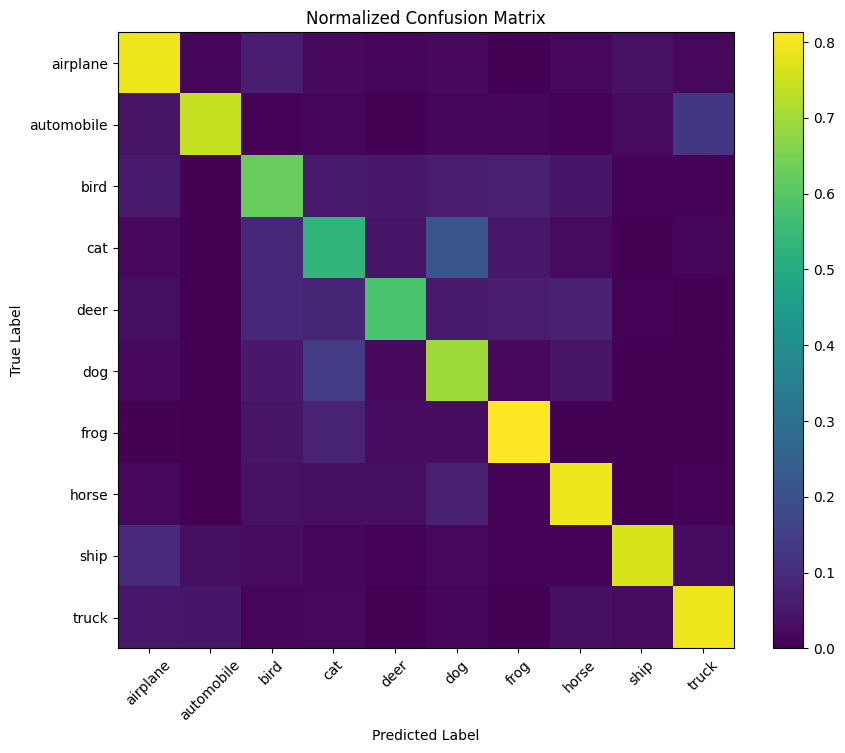

In [33]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [34]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_total[label] += 1
            if predicted[i].item() == label:
                class_correct[label] += 1

for i in range(10):
    print(f"{classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%")

airplane: 79.30%
automobile: 74.30%
bird: 62.40%
cat: 53.40%
deer: 58.20%
dog: 69.30%
frog: 81.30%
horse: 79.20%
ship: 76.40%
truck: 79.20%


In [35]:
np.save("confusion_matrix.npy", cm)
np.save("confusion_matrix_normalized.npy", cm_normalized)
print("Confusion matrices saved!")

Confusion matrices saved!


In [36]:
per_class_accuracy = {
    classes[i]: 100 * class_correct[i] / class_total[i]
    for i in range(10)
}

import json
with open("per_class_accuracy.json", "w") as f:
    json.dump(per_class_accuracy, f, indent=2)

print("Per-class accuracy saved!")

Per-class accuracy saved!


In [37]:
from torchvision import models

In [38]:
import torch.nn as nn
from torchvision import models

resnet_model = models.resnet18(weights=None)

# Modify first conv layer for CIFAR-10 (32x32 images)
resnet_model.conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

# Remove early maxpool because CIFAR-10 images are small
resnet_model.maxpool = nn.Identity()

# Change final layer to output 10 classes
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

resnet_model = resnet_model.to(device)

print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [39]:
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.001)

In [40]:
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform_clean = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [41]:
train_dataset_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform_aug
)

test_dataset_clean = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform_clean
)

train_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug,
    batch_size=64,
    shuffle=True
)

test_loader_clean = torch.utils.data.DataLoader(
    test_dataset_clean,
    batch_size=64,
    shuffle=False
)

In [42]:
resnet_train_losses = []
num_epochs_resnet = 10

for epoch in range(num_epochs_resnet):
    resnet_model.train()
    running_loss = 0.0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()

        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_aug)
    resnet_train_losses.append(epoch_loss)

    print(f"ResNet Epoch [{epoch+1}/{num_epochs_resnet}], Loss: {epoch_loss:.4f}")

print("Finished ResNet Training")

ResNet Epoch [1/10], Loss: 1.3636
ResNet Epoch [2/10], Loss: 0.8951
ResNet Epoch [3/10], Loss: 0.6949
ResNet Epoch [4/10], Loss: 0.5779
ResNet Epoch [5/10], Loss: 0.5040
ResNet Epoch [6/10], Loss: 0.4464
ResNet Epoch [7/10], Loss: 0.3978
ResNet Epoch [8/10], Loss: 0.3604
ResNet Epoch [9/10], Loss: 0.3267
ResNet Epoch [10/10], Loss: 0.3021
Finished ResNet Training


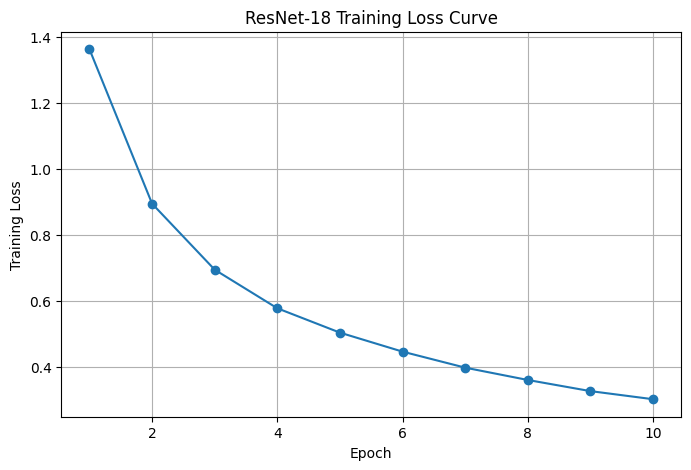

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(resnet_train_losses) + 1), resnet_train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ResNet-18 Training Loss Curve")
plt.grid(True)
plt.show()

In [44]:
correct = 0
total = 0

resnet_model.eval()

with torch.no_grad():
    for images, labels in test_loader_clean:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

resnet_accuracy = 100 * correct / total
print(f"ResNet-18 Test Accuracy: {resnet_accuracy:.2f}%")

ResNet-18 Test Accuracy: 87.50%


In [45]:
all_preds_resnet = []
all_labels_resnet = []

resnet_model.eval()

with torch.no_grad():
    for images, labels in test_loader_clean:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)
print(cm_resnet)

[[890   9  40  17   7   3   0   3  23   8]
 [ 11 948   2   3   1   2   0   1   2  30]
 [ 27   1 870  29  31  28   4   3   6   1]
 [  9   0  40 813  19  90  10  10   7   2]
 [ 10   2  37  39 888   6   2  15   1   0]
 [  3   0  23  95  20 843   3  11   0   2]
 [ 11   1  83  73  32  21 776   1   1   1]
 [  8   1  18  27  21  51   0 869   3   2]
 [ 38  14   4   4   1   1   0   0 930   8]
 [ 23  27   4   9   0   1   1   0  12 923]]


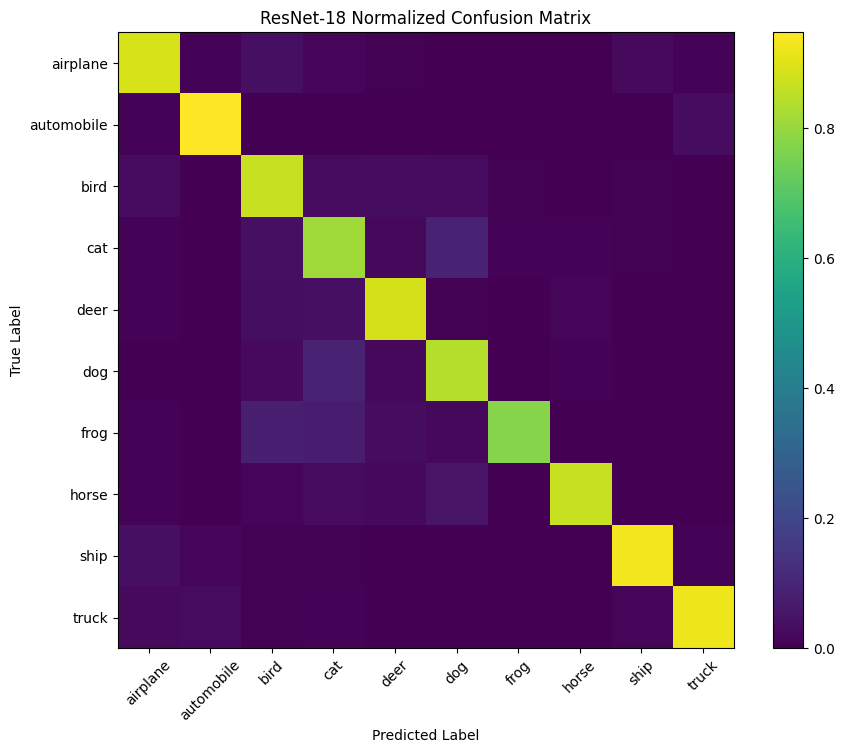

In [46]:
cm_resnet_normalized = cm_resnet.astype("float") / cm_resnet.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_resnet_normalized, interpolation='nearest')
plt.title("ResNet-18 Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [47]:
class_correct_resnet = [0] * 10
class_total_resnet = [0] * 10

resnet_model.eval()
with torch.no_grad():
    for images, labels in test_loader_clean:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_total_resnet[label] += 1
            if predicted[i].item() == label:
                class_correct_resnet[label] += 1

for i in range(10):
    print(f"{classes[i]}: {100 * class_correct_resnet[i] / class_total_resnet[i]:.2f}%")

airplane: 89.00%
automobile: 94.80%
bird: 87.00%
cat: 81.30%
deer: 88.80%
dog: 84.30%
frog: 77.60%
horse: 86.90%
ship: 93.00%
truck: 92.30%


In [48]:
print(f"Simple CNN Test Accuracy: {accuracy:.2f}%")
print(f"ResNet-18 Test Accuracy: {resnet_accuracy:.2f}%")
print(f"Improvement: {resnet_accuracy - accuracy:.2f} percentage points")

Simple CNN Test Accuracy: 70.43%
ResNet-18 Test Accuracy: 87.50%
Improvement: 17.07 percentage points


In [49]:
cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)

print("ResNet-18 Confusion Matrix:")
print(cm_resnet)

ResNet-18 Confusion Matrix:
[[890   9  40  17   7   3   0   3  23   8]
 [ 11 948   2   3   1   2   0   1   2  30]
 [ 27   1 870  29  31  28   4   3   6   1]
 [  9   0  40 813  19  90  10  10   7   2]
 [ 10   2  37  39 888   6   2  15   1   0]
 [  3   0  23  95  20 843   3  11   0   2]
 [ 11   1  83  73  32  21 776   1   1   1]
 [  8   1  18  27  21  51   0 869   3   2]
 [ 38  14   4   4   1   1   0   0 930   8]
 [ 23  27   4   9   0   1   1   0  12 923]]


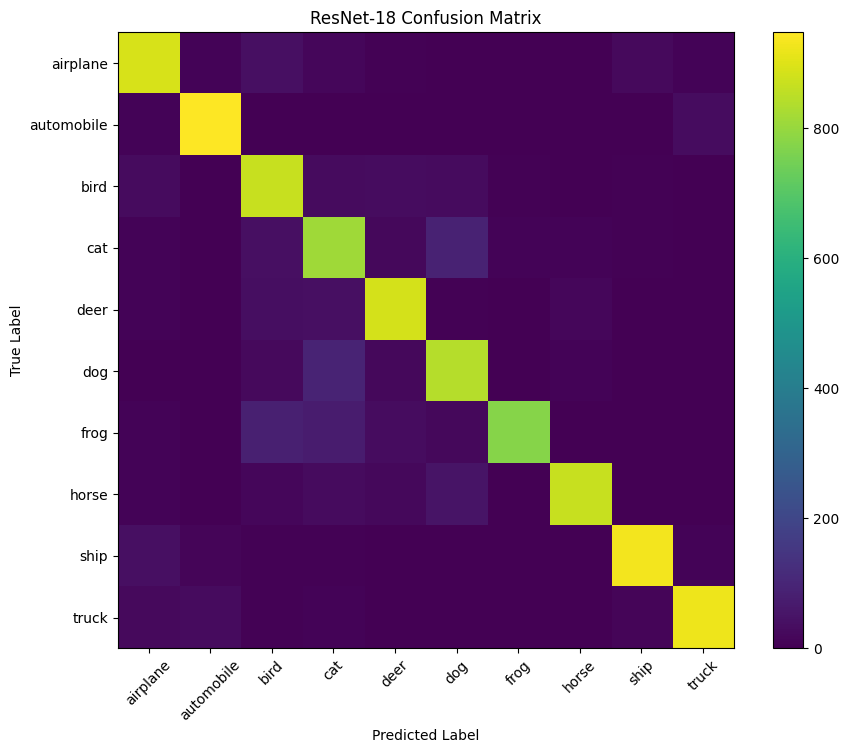

In [50]:
plt.figure(figsize=(10,8))
plt.imshow(cm_resnet, interpolation='nearest')
plt.title("ResNet-18 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

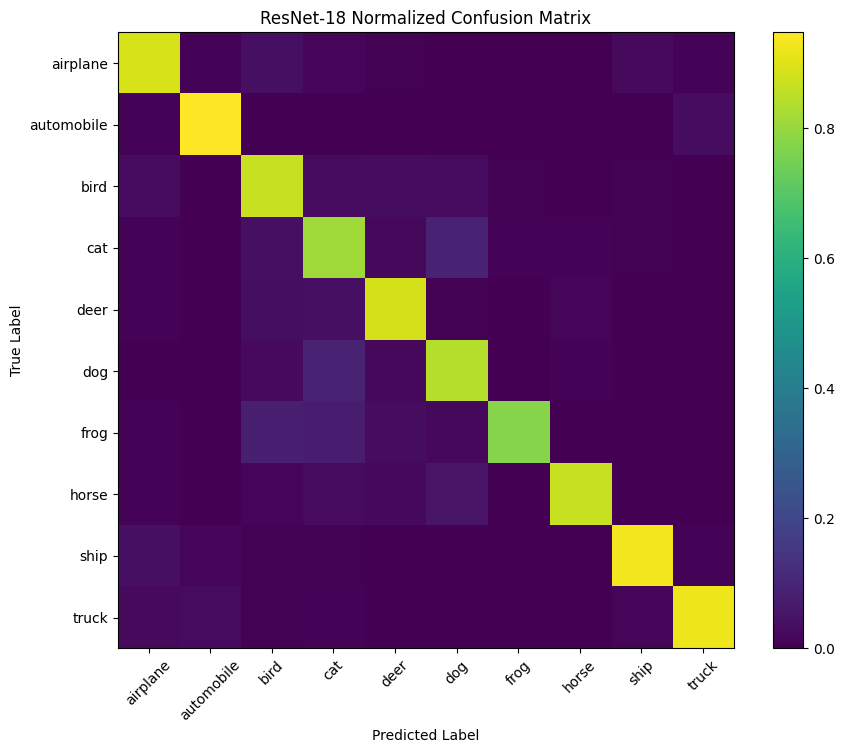

In [51]:
cm_resnet_norm = cm_resnet.astype("float") / cm_resnet.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
plt.imshow(cm_resnet_norm, interpolation='nearest')
plt.title("ResNet-18 Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [52]:
print("MODEL COMPARISON")
print("------------------")
print(f"Simple CNN Accuracy: {accuracy:.2f}%")
print(f"ResNet-18 Accuracy:  {resnet_accuracy:.2f}%")
print(f"Improvement:         {resnet_accuracy - accuracy:.2f} percentage points")

MODEL COMPARISON
------------------
Simple CNN Accuracy: 70.43%
ResNet-18 Accuracy:  87.50%
Improvement:         17.07 percentage points


In [53]:
torch.save(model.state_dict(), "cnn_baseline_model.pth")
torch.save(resnet_model.state_dict(), "resnet18_model.pth")

print("Models saved!")

Models saved!


In [54]:
import json

with open("cnn_training_losses.json", "w") as f:
    json.dump(train_losses, f)

with open("resnet_training_losses.json", "w") as f:
    json.dump(resnet_train_losses, f)

print("Training curves saved!")

Training curves saved!


In [55]:
import numpy as np

np.save("cnn_confusion_matrix.npy", cm)
np.save("resnet_confusion_matrix.npy", cm_resnet)

np.save("cnn_confusion_matrix_normalized.npy", cm_normalized)
np.save("resnet_confusion_matrix_normalized.npy", cm_resnet_norm)

print("Confusion matrices saved!")

Confusion matrices saved!


In [56]:
per_class_resnet = {
    classes[i]: float(100 * class_correct_resnet[i] / class_total_resnet[i])
    for i in range(10)
}

with open("resnet_per_class_accuracy.json", "w") as f:
    json.dump(per_class_resnet, f, indent=4)

print("Per-class accuracy saved!")

Per-class accuracy saved!


In [57]:
!zip -r cifar10_resnet_project_backup.zip .

  adding: per_class_accuracy.json (deflated 39%)
  adding: training_losses.json (deflated 30%)
  adding: cnn_confusion_matrix_normalized.npy (deflated 49%)
  adding: resnet_training_losses.json (deflated 44%)
  adding: data/ (stored 0%)
  adding: data/cifar-10-python.tar.gz (deflated 0%)
  adding: data/cifar-10-batches-py/ (stored 0%)
  adding: data/cifar-10-batches-py/readme.html (stored 0%)
  adding: data/cifar-10-batches-py/data_batch_1 (deflated 9%)
  adding: data/cifar-10-batches-py/data_batch_3 (deflated 8%)
  adding: data/cifar-10-batches-py/test_batch (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_4 (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_2 (deflated 8%)
  adding: data/cifar-10-batches-py/batches.meta (deflated 12%)
  adding: data/cifar-10-batches-py/data_batch_5 (deflated 8%)
  adding: resnet_confusion_matrix.npy (deflated 71%)
  adding: resnet_confusion_matrix_normalized.npy (deflated 54%)
  adding: resnet_per_class_accuracy.json (deflated 41%

In [58]:
from google.colab import files
files.download("cifar10_resnet_project_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

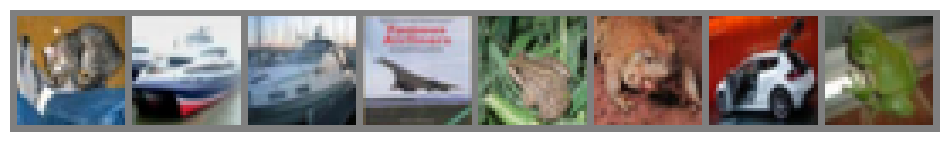

True labels:      ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']
Predicted labels: ['cat', 'ship', 'ship', 'truck', 'frog', 'frog', 'automobile', 'bird']


In [59]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(test_loader_clean)
images, labels = next(dataiter)

images_device = images.to(device)
labels_device = labels.to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(images_device)
    _, predicted = torch.max(outputs, 1)

imshow(torchvision.utils.make_grid(images[:8]))

print("True labels:     ", [classes[labels[j]] for j in range(8)])
print("Predicted labels:", [classes[predicted.cpu()[j]] for j in range(8)])

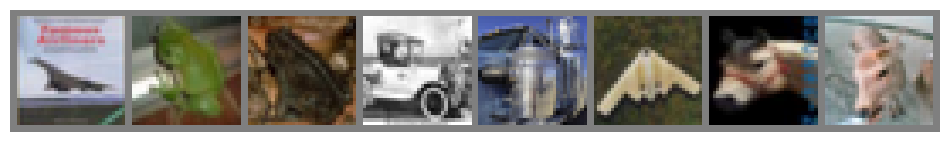

Image 1: true = airplane, predicted = truck
Image 2: true = frog, predicted = bird
Image 3: true = frog, predicted = cat
Image 4: true = automobile, predicted = truck
Image 5: true = truck, predicted = ship
Image 6: true = airplane, predicted = dog
Image 7: true = horse, predicted = cat
Image 8: true = deer, predicted = cat


In [60]:
mistake_images = []
mistake_true = []
mistake_pred = []

resnet_model.eval()
with torch.no_grad():
    for images, labels in test_loader_clean:
        images_device = images.to(device)
        labels_device = labels.to(device)

        outputs = resnet_model(images_device)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i].item() != labels_device[i].item():
                mistake_images.append(images[i])  # keep CPU version for plotting
                mistake_true.append(classes[labels[i].item()])
                mistake_pred.append(classes[predicted[i].item()])

            if len(mistake_images) == 8:
                break
        if len(mistake_images) == 8:
            break

imshow(torchvision.utils.make_grid(mistake_images))

for i in range(len(mistake_images)):
    print(f"Image {i+1}: true = {mistake_true[i]}, predicted = {mistake_pred[i]}")

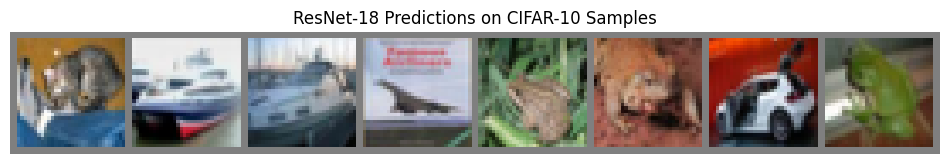

In [61]:
grid = torchvision.utils.make_grid(images[:8])
grid = grid / 2 + 0.5
npimg = grid.numpy()

plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis("off")
plt.title("ResNet-18 Predictions on CIFAR-10 Samples")
plt.savefig("resnet_predictions.png", bbox_inches="tight")
plt.show()

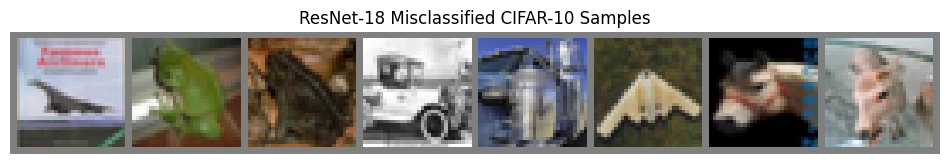

In [62]:
mistake_grid = torchvision.utils.make_grid(mistake_images)
mistake_grid = mistake_grid / 2 + 0.5
npimg = mistake_grid.numpy()

plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis("off")
plt.title("ResNet-18 Misclassified CIFAR-10 Samples")
plt.savefig("resnet_mistakes.png", bbox_inches="tight")
plt.show()

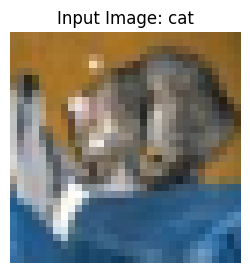

In [63]:
sample_image, sample_label = test_dataset_clean[0]

plt.figure(figsize=(3,3))
img = sample_image / 2 + 0.5
plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title(f"Input Image: {classes[sample_label]}")
plt.axis("off")
plt.show()

In [64]:
sample_batch = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = resnet_model.conv1(sample_batch)

print("Feature map shape:", feature_maps.shape)

Feature map shape: torch.Size([1, 64, 32, 32])


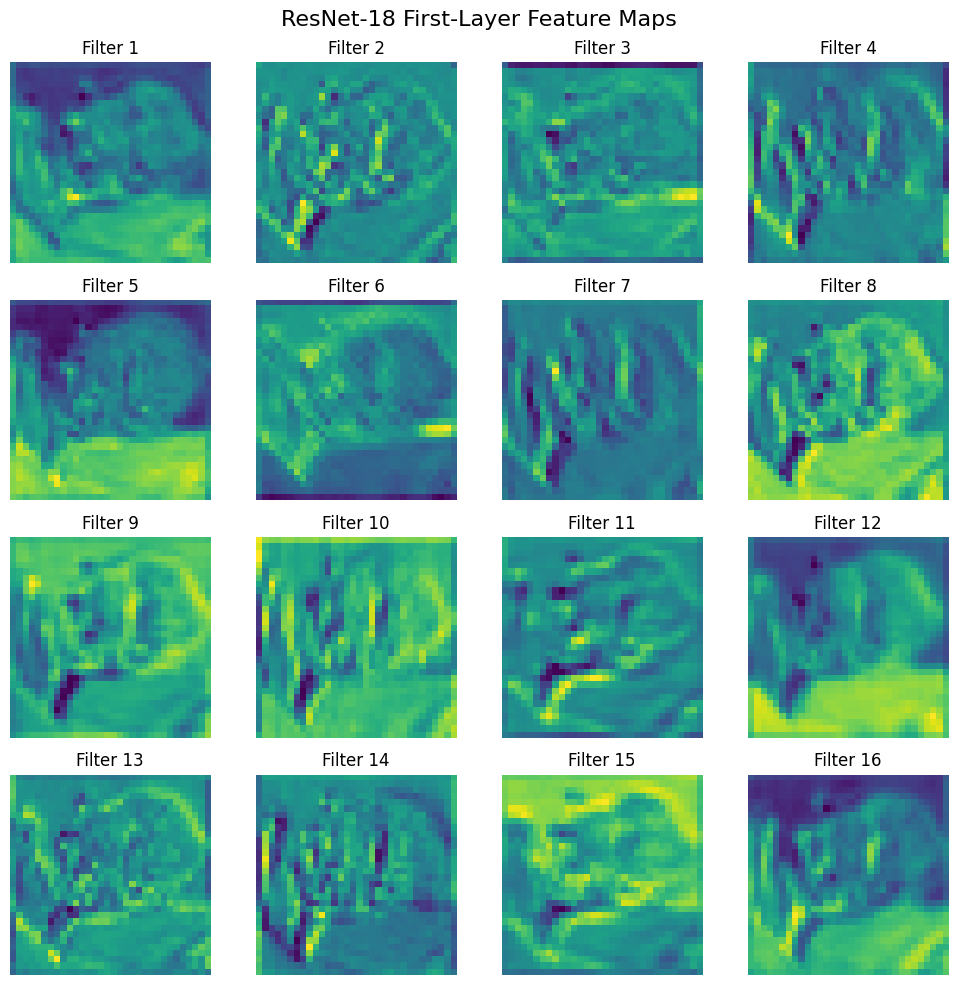

In [65]:
feature_maps = feature_maps.squeeze(0).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.axis("off")
    ax.set_title(f"Filter {i+1}")

plt.suptitle("ResNet-18 First-Layer Feature Maps", fontsize=16)
plt.tight_layout()
plt.show()

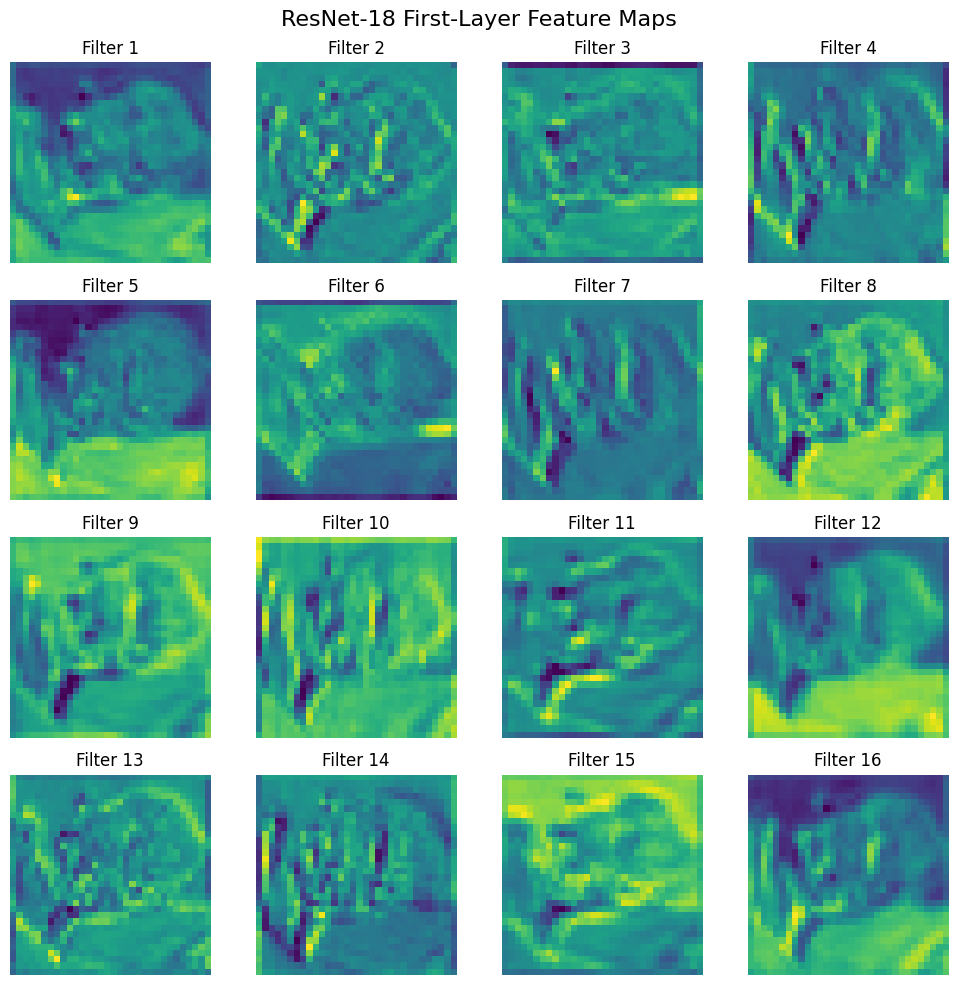

In [66]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.axis("off")
    ax.set_title(f"Filter {i+1}")

plt.suptitle("ResNet-18 First-Layer Feature Maps", fontsize=16)
plt.tight_layout()
plt.savefig("resnet_feature_maps.png", bbox_inches="tight")
plt.show()

In [67]:
from PIL import Image
from google.colab import files
import torchvision.transforms as transforms

In [68]:
interactive_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [69]:
uploaded = files.upload()

Saving IMG_8748.jpg to IMG_8748.jpg


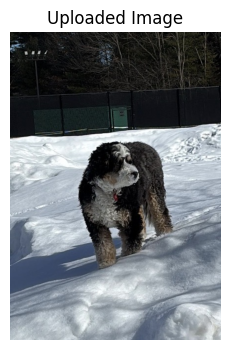

Predicted label: dog
Confidence: 99.0838348865509 %


In [70]:
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

img_tensor = interactive_transform(img).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(img_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

print("Predicted label:", classes[predicted_class])
print("Confidence:", float(probabilities[0][predicted_class]) * 100, "%")

Saving IMG_8748.jpg to IMG_8748 (1).jpg


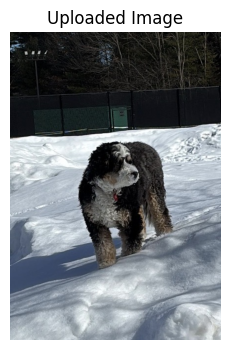

Top 3 predictions:
1. dog: 99.08%
2. ship: 0.49%
3. cat: 0.24%


In [71]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

img_tensor = interactive_transform(img).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(img_tensor)
    probabilities = torch.softmax(outputs, dim=1)

top_probs, top_indices = torch.topk(probabilities, 3)

print("Top 3 predictions:")
for i in range(3):
    label = classes[top_indices[0][i].item()]
    prob = top_probs[0][i].item() * 100
    print(f"{i+1}. {label}: {prob:.2f}%")

In [72]:
def predict_uploaded_image(model, classes, device):
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    img = Image.open(filename).convert("RGB")

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)

    top_probs, top_indices = torch.topk(probabilities, 3)

    print("Top 3 predictions:")
    for i in range(3):
        label = classes[top_indices[0][i].item()]
        prob = top_probs[0][i].item() * 100
        print(f"{i+1}. {label}: {prob:.2f}%")

Saving IMG_8748.jpg to IMG_8748 (2).jpg


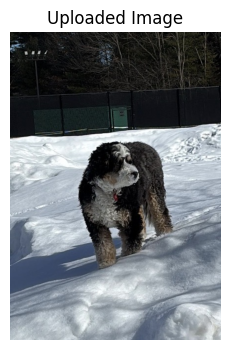

Top 3 predictions:
1. dog: 99.08%
2. ship: 0.49%
3. cat: 0.24%


In [73]:
predict_uploaded_image(resnet_model, classes, device)

In [74]:
!pip install gradio

In [75]:
import gradio as gr
from PIL import Image

def predict_image_gradio(img):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    resnet_model.eval()
    with torch.no_grad():
        outputs = resnet_model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]

    return {classes[i]: float(probabilities[i]) for i in range(len(classes))}

demo = gr.Interface(
    fn=predict_image_gradio,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="CIFAR-10 ResNet-18 Classifier",
    description="Upload an image and the model will predict one of the CIFAR-10 classes."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cd897925a49043761.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [76]:
demo = gr.Interface(
    fn=predict_image_gradio,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="CIFAR-10 Image Classifier — David Schechter",
    description="Upload an image and the trained ResNet-18 model will classify it into one of the CIFAR-10 categories."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f9cd4a0b713f6cf741.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [77]:
torch.save(model.state_dict(), "cnn_baseline_model.pth")
torch.save(resnet_model.state_dict(), "resnet18_model.pth")

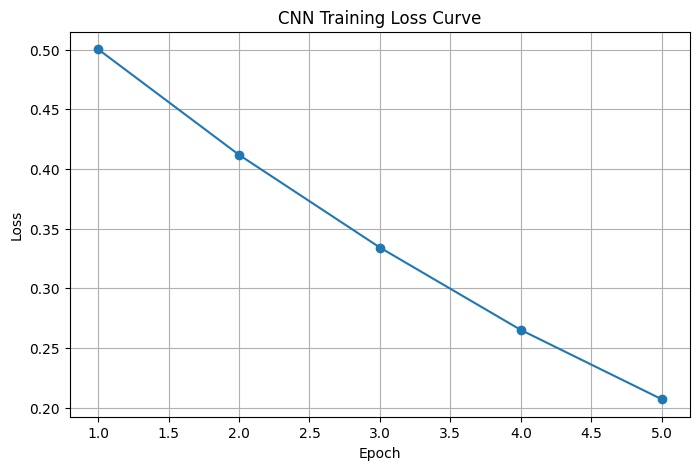

In [78]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss Curve")
plt.grid(True)
plt.savefig("cnn_training_curve.png")
plt.show()

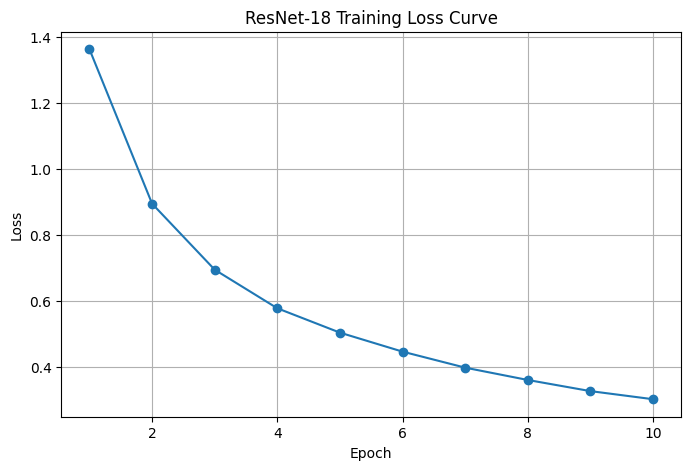

In [79]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(resnet_train_losses)+1), resnet_train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Training Loss Curve")
plt.grid(True)
plt.savefig("resnet_training_curve.png")
plt.show()

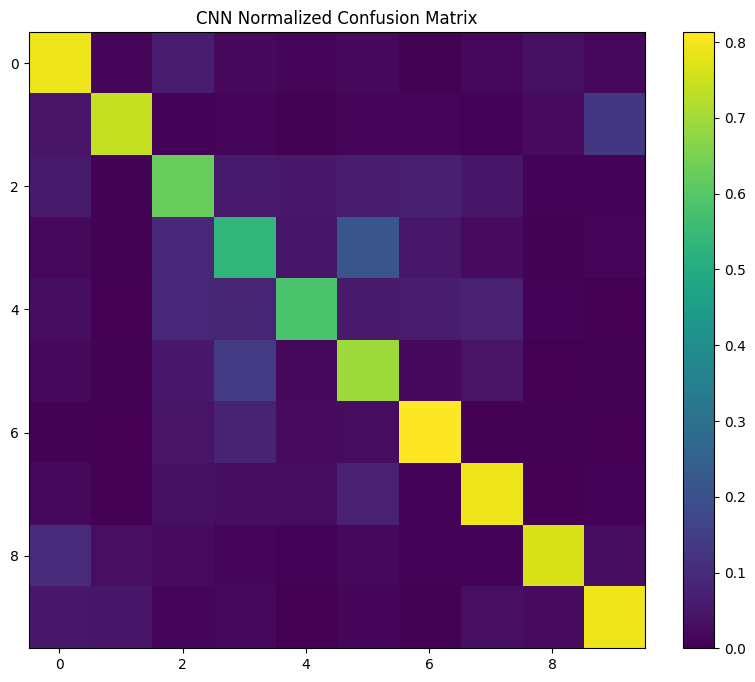

In [80]:
plt.figure(figsize=(10,8))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title("CNN Normalized Confusion Matrix")
plt.colorbar()
plt.savefig("cnn_confusion_matrix.png")
plt.show()

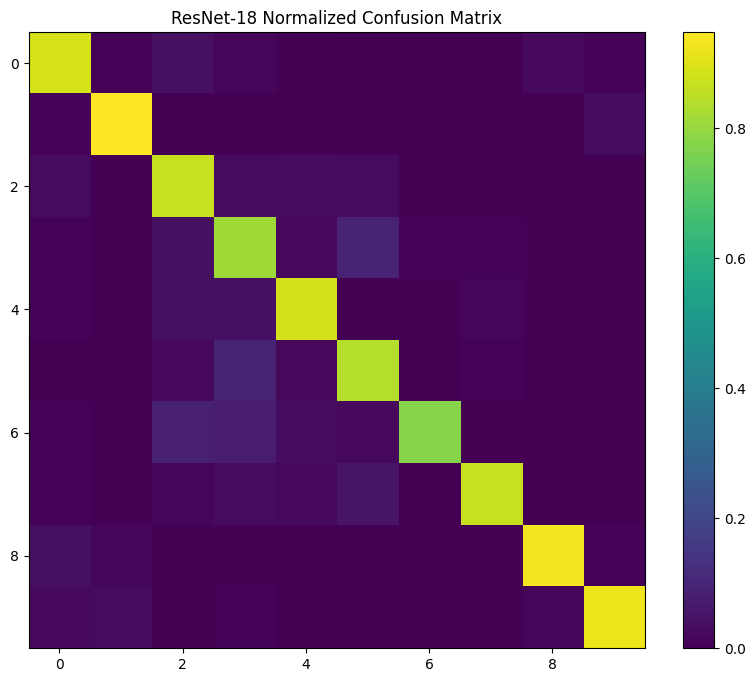

In [81]:
plt.figure(figsize=(10,8))
plt.imshow(cm_resnet_norm, interpolation='nearest')
plt.title("ResNet-18 Normalized Confusion Matrix")
plt.colorbar()
plt.savefig("resnet_confusion_matrix.png")
plt.show()

In [82]:
!zip -r cifar10_resnet_project.zip .

  adding: per_class_accuracy.json (deflated 39%)
  adding: resnet_training_curve.png (deflated 10%)
  adding: training_losses.json (deflated 30%)
  adding: cnn_confusion_matrix_normalized.npy (deflated 49%)
  adding: cnn_confusion_matrix.png (deflated 29%)
  adding: resnet_feature_maps.png (deflated 9%)
  adding: .gradio/ (stored 0%)
  adding: .gradio/certificate.pem (deflated 24%)
  adding: resnet_training_losses.json (deflated 44%)
  adding: resnet_mistakes.png (deflated 4%)
  adding: data/ (stored 0%)
  adding: data/cifar-10-python.tar.gz (deflated 0%)
  adding: data/cifar-10-batches-py/ (stored 0%)
  adding: data/cifar-10-batches-py/readme.html (stored 0%)
  adding: data/cifar-10-batches-py/data_batch_1 (deflated 9%)
  adding: data/cifar-10-batches-py/data_batch_3 (deflated 8%)
  adding: data/cifar-10-batches-py/test_batch (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_4 (deflated 8%)
  adding: data/cifar-10-batches-py/data_batch_2 (deflated 8%)
  adding: data/cifar-10

In [83]:
from google.colab import files
files.download("cifar10_resnet_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

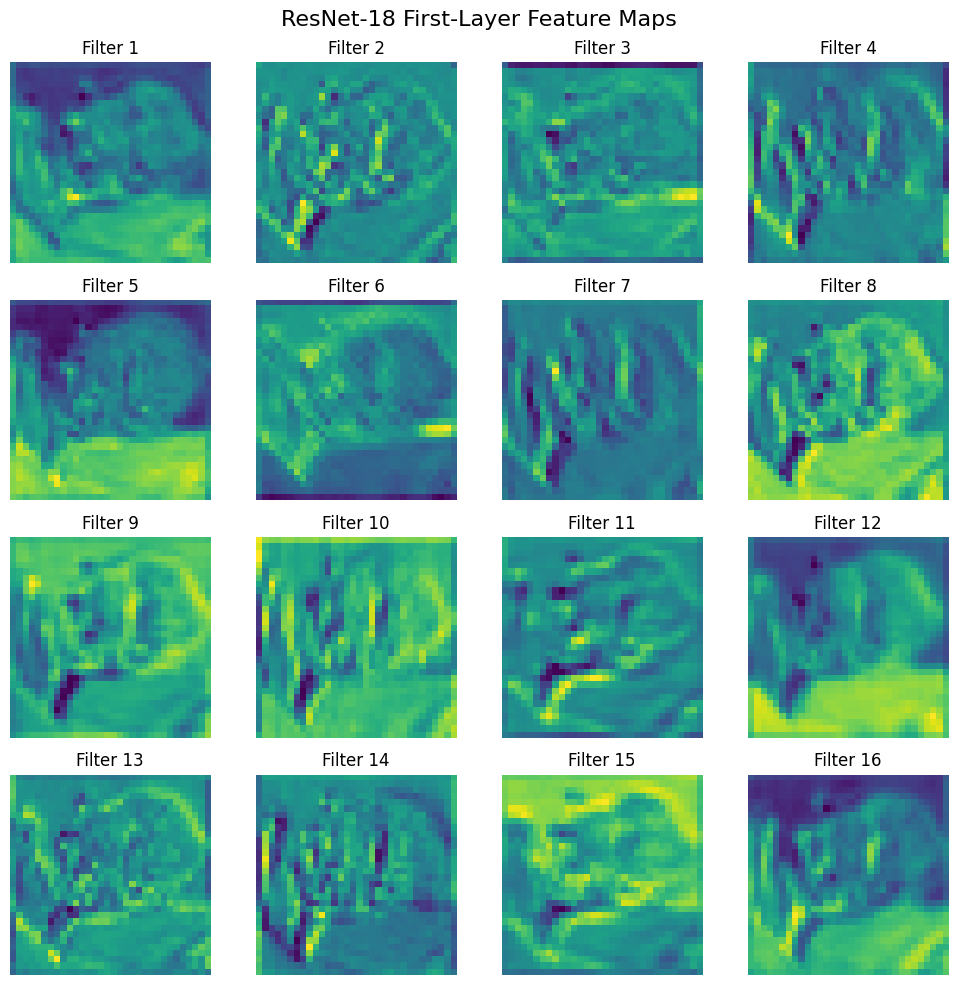

In [84]:
feature_maps = feature_maps.squeeze(0).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="viridis")
    ax.axis("off")
    ax.set_title(f"Filter {i+1}")

plt.suptitle("ResNet-18 First-Layer Feature Maps", fontsize=16)
plt.tight_layout()
plt.show()

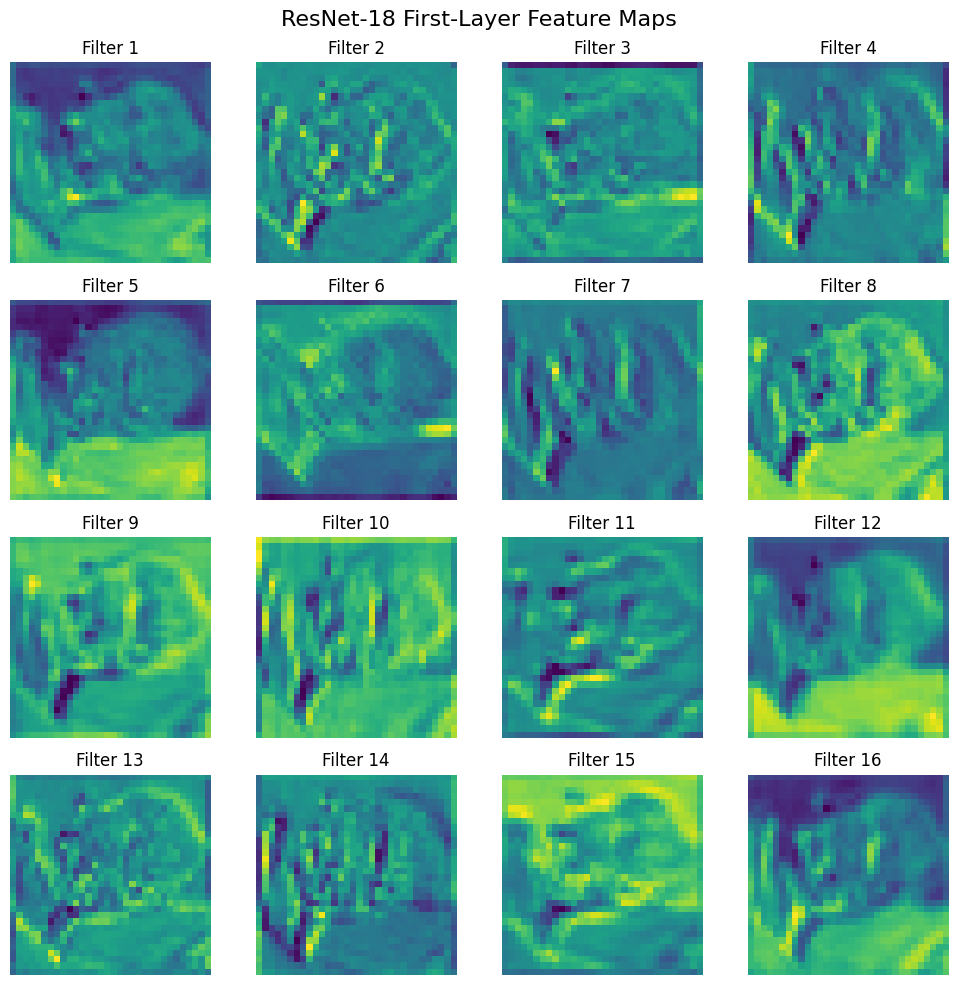

In [85]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="viridis")
    ax.axis("off")
    ax.set_title(f"Filter {i+1}")

plt.suptitle("ResNet-18 First-Layer Feature Maps", fontsize=16)
plt.tight_layout()
plt.savefig("resnet_feature_maps.png", bbox_inches="tight")
plt.show()